## 1. バネの実験データ

バネにおもりを吊るした結果、以下の2点が観測されました。
* **$(1, 2)$** ： 1cm伸びたとき、重さは2g
* **$(2, 4)$** ： 2cm伸びたとき、重さは4g

この関係をモデル **$y = w \times x$** で説明します。

In [ ]:
# 実験データ（x: 伸び, y: 重さ）
x1, y1 = 1, 2
x2, y2 = 2, 4
# Pythonでは、カンマで区切ることで複数の変数に値を代入できます。

# 傾きw。まずは 0 としてみる
w = 0

print("x1", x1)
print("y1", y1)
print("x2", x2)
print("y2", y2)
print("w", w)

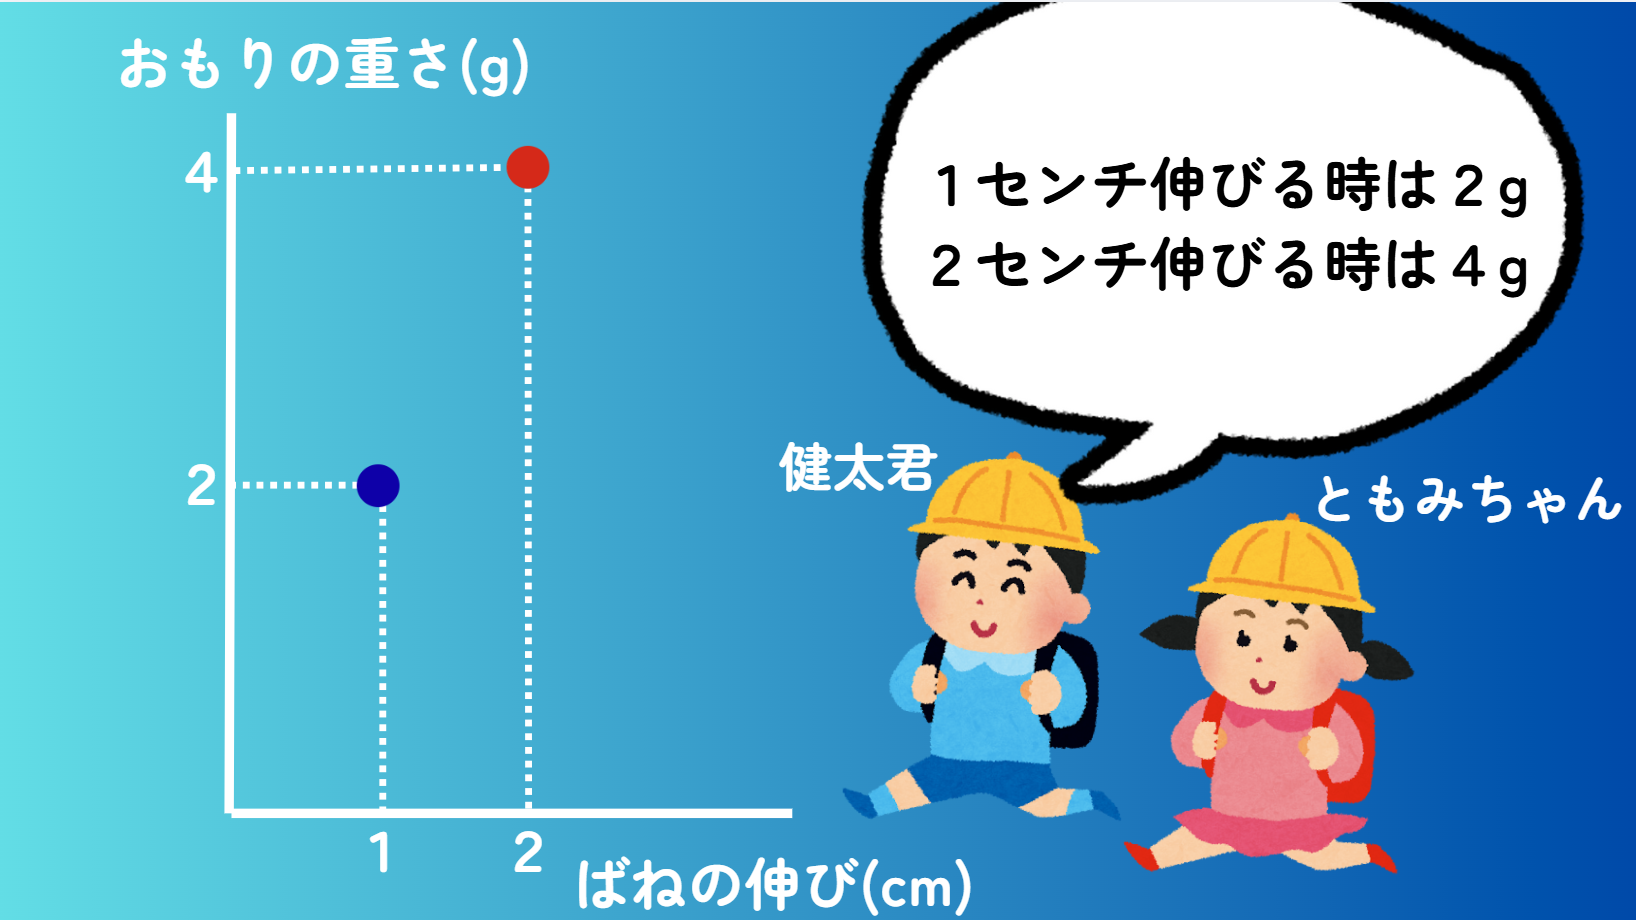

---

## 2. 予測してみる

定義したモデルを使って、予測値 $y_{pred}$ を計算します。

```python
出力: y_pred1, y_pred2（モデルによる予測値）
式: w * x
```
- 傾き w と入力 x を掛けることで、モデルの予測値を計算します。

In [ ]:
# モデル：y = w * x
y_pred1 = # TODO: 出力 = 式
y_pred2 = # TODO: 出力 = 式
# 復習:Pythonでは*を使って変数同士を掛け算できます。

print("y_pred1", y_pred1)
print("y_pred2", y_pred2) 

> 現在は $w=0$ なので、予測結果も $0$ です。本物のデータ（2g, 4g）とはズレています。

### 関数としてモデルを定義する

同じ式 $y = w \times x$ を、関数 `model_function` として定義して使うこともできます。
（以降の章で式が複雑になっても、`model_function(w, x)` の形で計算を統一できます。）

```python
出力: y_pred1, y_pred2（モデルによる予測値）
関数: model_function
引数: w（傾き）, x（入力）
```
- 関数 `model_function` に重み w と入力 x を渡して予測値を計算します。

In [ ]:
def model_function(w, x):
    return w * x
# 毎回掛け算の式を書くのは面倒なので、関数を定義してみましょう。
# カンマで区切ると、複数の引数を関数に渡すことができます。

w = 1
# 関数 model_function を使って同じ計算をする
y_pred1 = # TODO: 出力 = 関数(引数)
y_pred2 = # TODO: 出力 = 関数(引数)

print("y_pred1", y_pred1)
print("y_pred2", y_pred2)  

傾きが正しくないので、予測結果も間違っています。この予測結果とのズレを最小にする傾きwを
見つけることが今回の目標です！

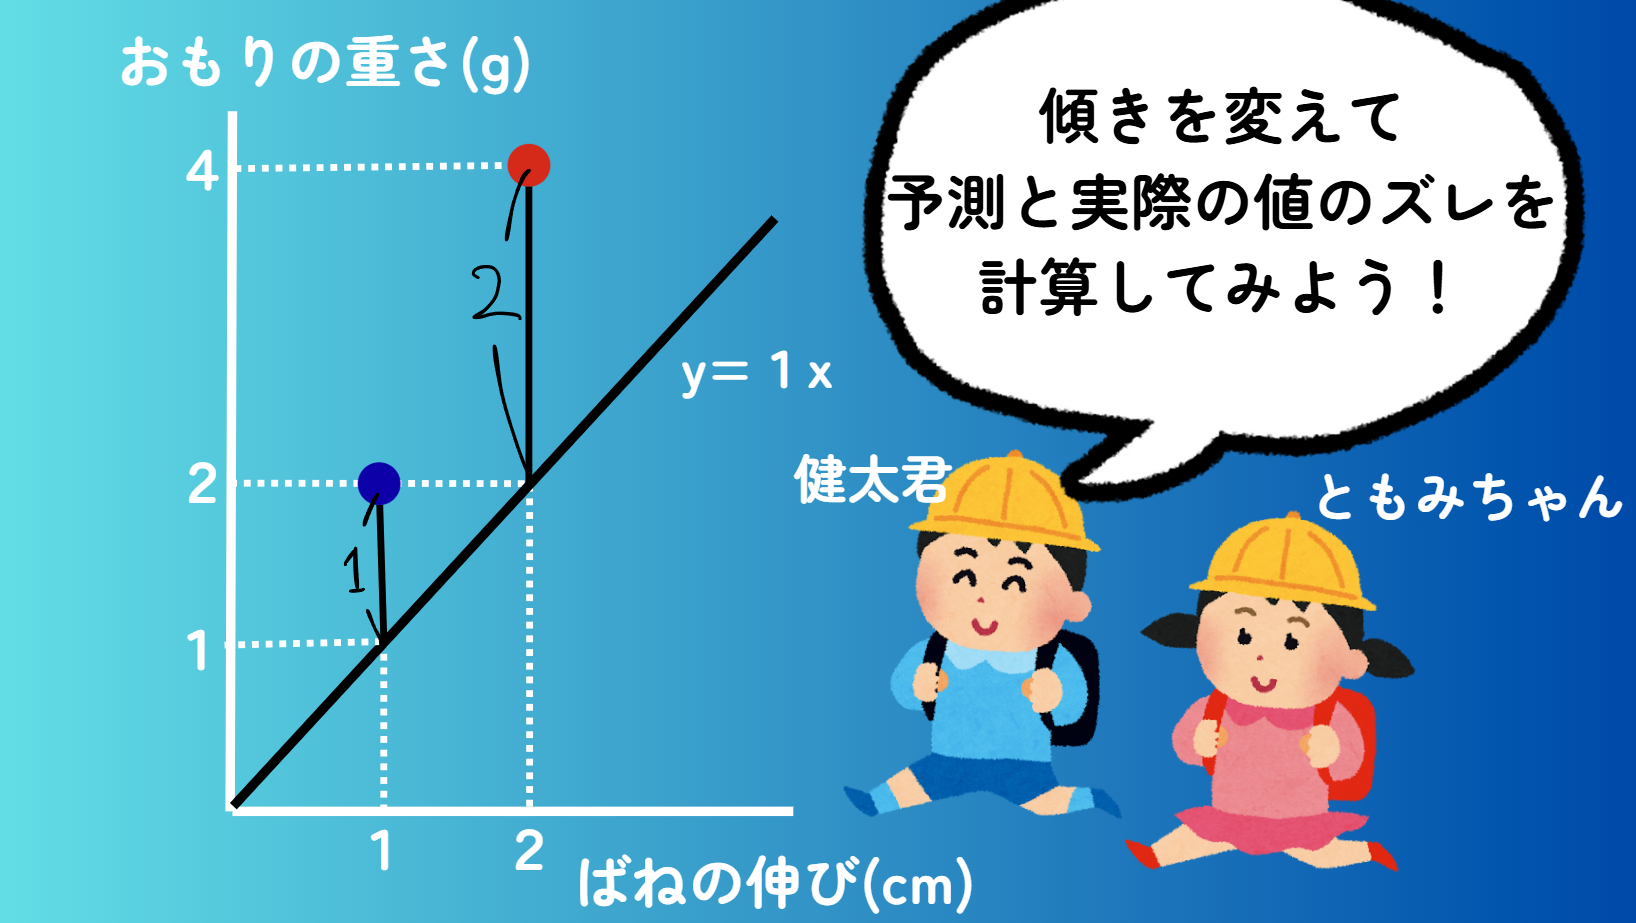

---

## 3. 損失関数（二乗誤差 → 平均二乗誤差）

予測がどれだけ外れているかを「損失（ロス）」として計算します。
まずは **サンプルごとの二乗誤差** を計算します。
今回は **$L = (y_{pred} - y_{true})^2$** を使います。
予測値と真値の誤差を二乗することで、負の値がなくなり、大きい誤差ほど大きな損失になります。

In [ ]:
# サンプルごとの損失（= 二乗誤差）
loss1 = # TODO: 出力 = 式
loss2 = # TODO: 出力 = 式
# 復習:Pythonでは**を使って変数のべき乗を計算できます。
# y_predとyの差を二乗して、損失を計算してみましょう。

print("loss1", loss1)
print("loss2", loss2)  

### 関数として損失を定義する

`model_function` と同様に、損失（ここでは二乗誤差）も関数として定義できます。


```python
出力: loss1, loss2（各サンプルの二乗誤差）
関数: loss_function
引数: y_pred（予測値）, y_true（真値）
```
- 損失関数 `loss_function` に予測値と真値を渡して二乗誤差を計算します。

In [ ]:
def loss_function(y_pred, y_true):
    return (y_pred - y_true)**2

# 関数 loss_function を使って同じ計算をする
loss1 =  # TODO: 出力 = 関数(引数)
loss2 =  # TODO: 出力 = 関数(引数)

print("loss1", loss1)
print("loss2", loss2) 

### 2乗誤差

次に、サンプルごとの損失 $loss_1, loss_2$ の平均をとって、全体の損失 **loss** を計算します。
（機械学習では **loss と書いたら、サンプル平均（経験損失）** を指すことが多いです。ここでは二乗誤差の平均なので、平均二乗誤差 (MSEと言います) と同じです。）

$$loss = \frac{loss_1 + loss_2}{2} = \frac{(y_{pred1} - y_{true1})^2 + (y_{pred2} - y_{true2})^2}{2}$$

```python
出力: loss（平均二乗誤差/MSE）
式: (loss1 + loss2) / 2
```
- 各サンプルの損失の平均を計算します。これが機械学習で最小化する目標値（loss）になります。

In [ ]:
# サンプル平均の損失 (loss)
loss = # TODO: 出力 = 式  あまり難しく考えないで！

print("loss", loss) 

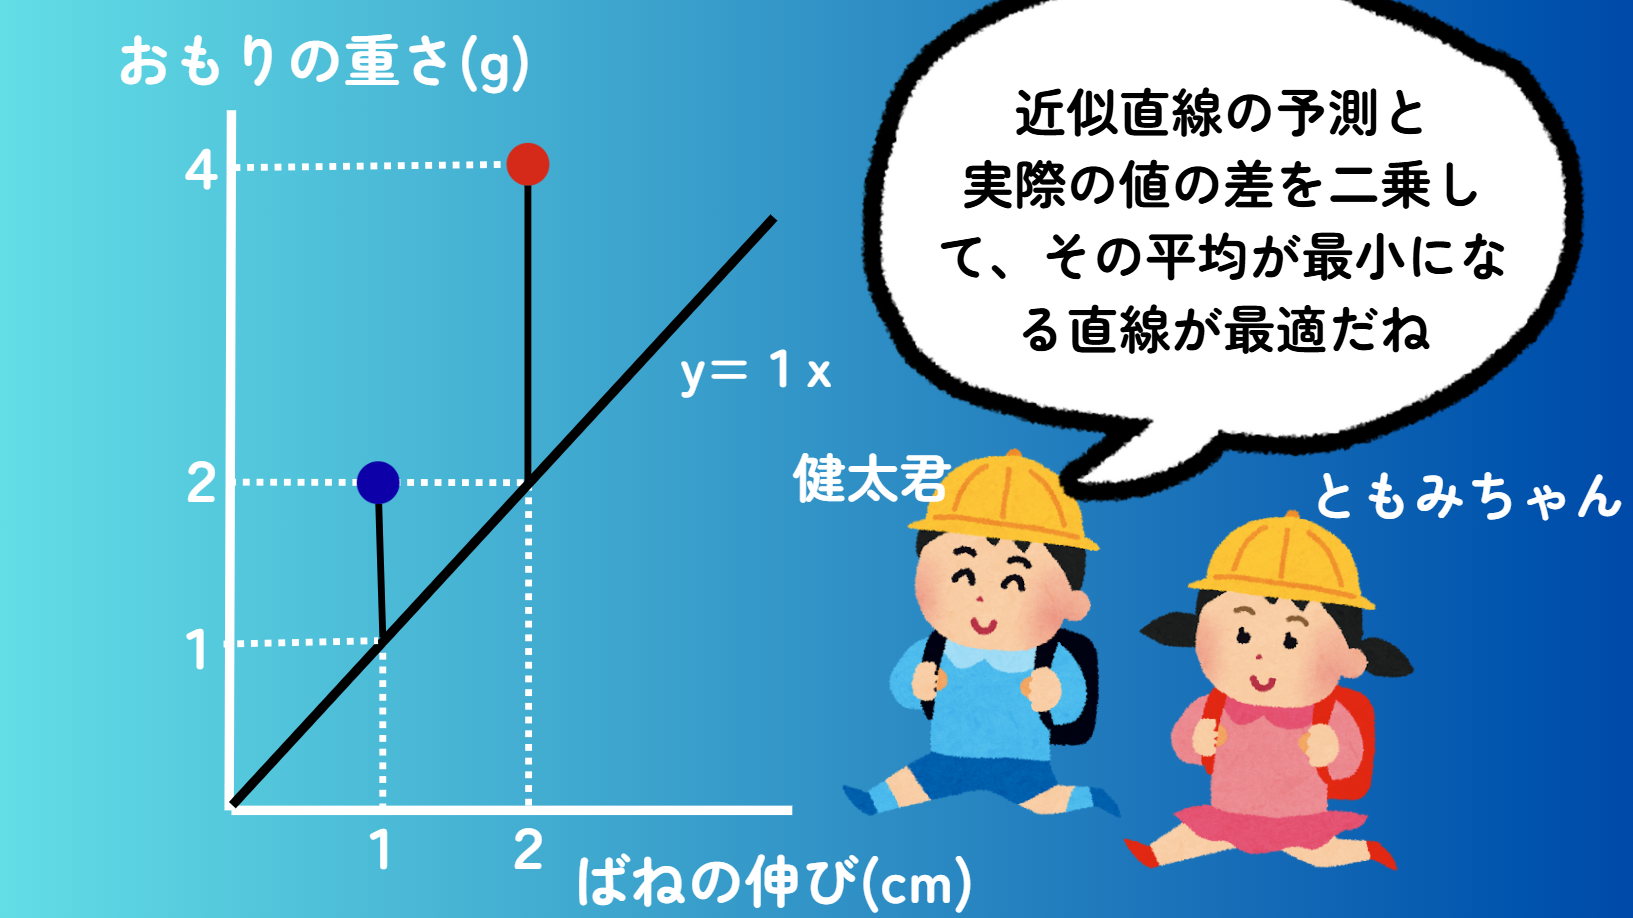

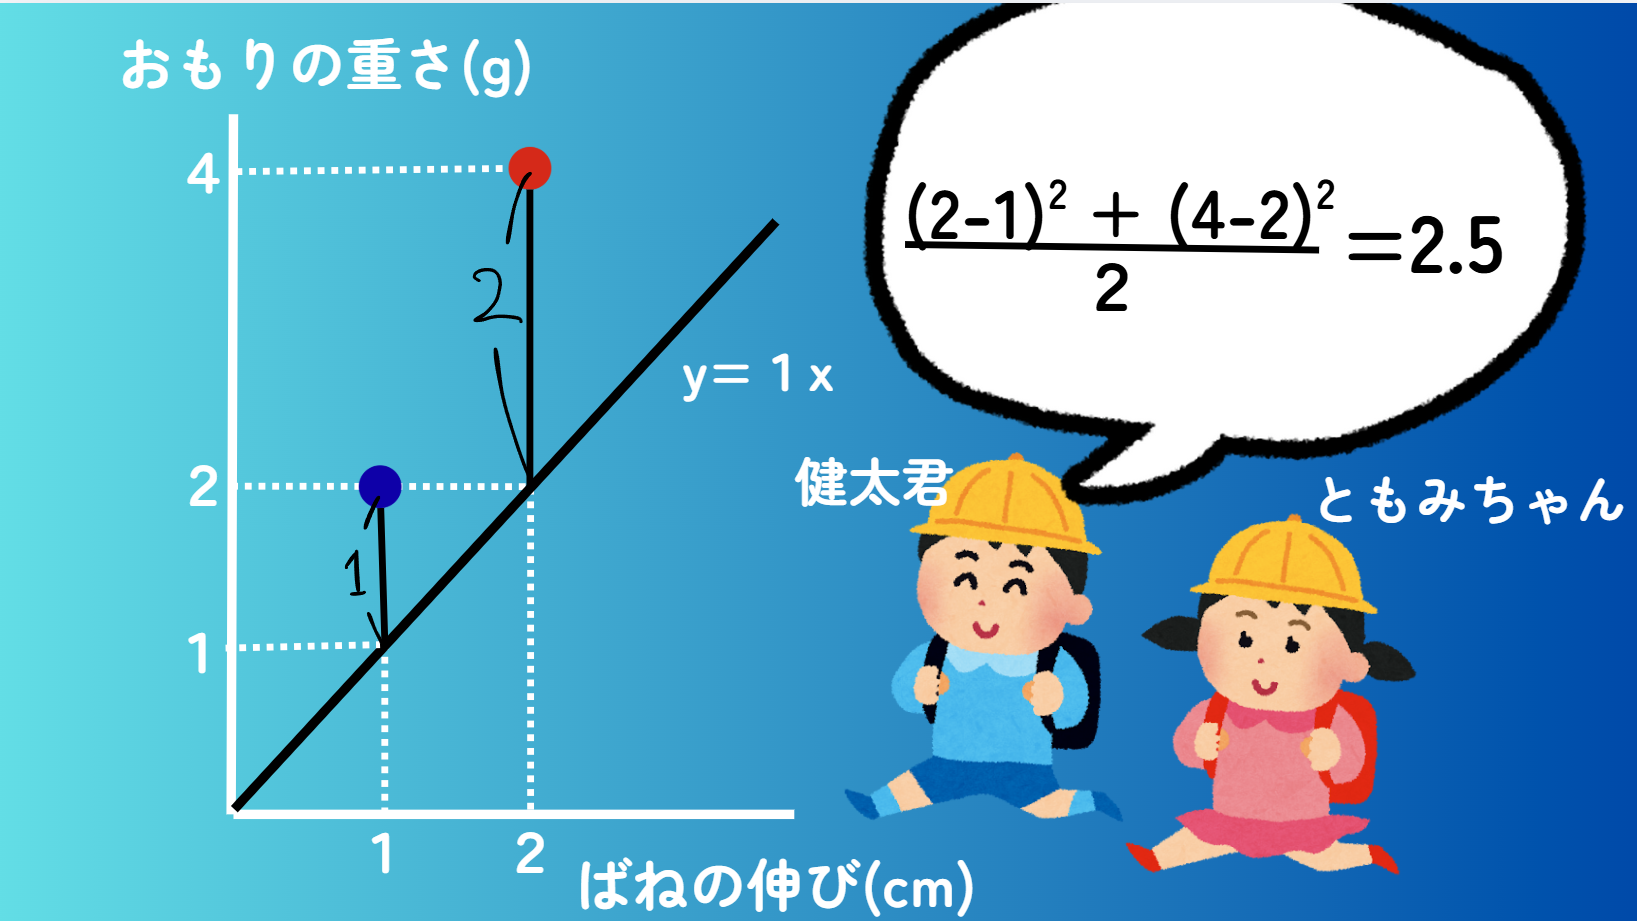

---

## 4. 損失関数の概念：wを変えるとどうなる？

もし $w$ を正解の **2** に書き換えて、上のコードをもう一度実行したらどうなるでしょうか？
loss（サンプル平均の損失）の式を $w$ について整理すると、以下のようになります。

$$loss = \{ (w \cdot 1 - 2)^2 + (w \cdot 2 - 4)^2 \} \div 2$$
$$loss = 2.5(w - 2)^2$$


> **解説**
> この式は **$w=2$** の時に最小値（谷の底）になります。
> $w$ を少しずつ動かして、この「谷の底」にたどり着くことが機械学習のゴールです。

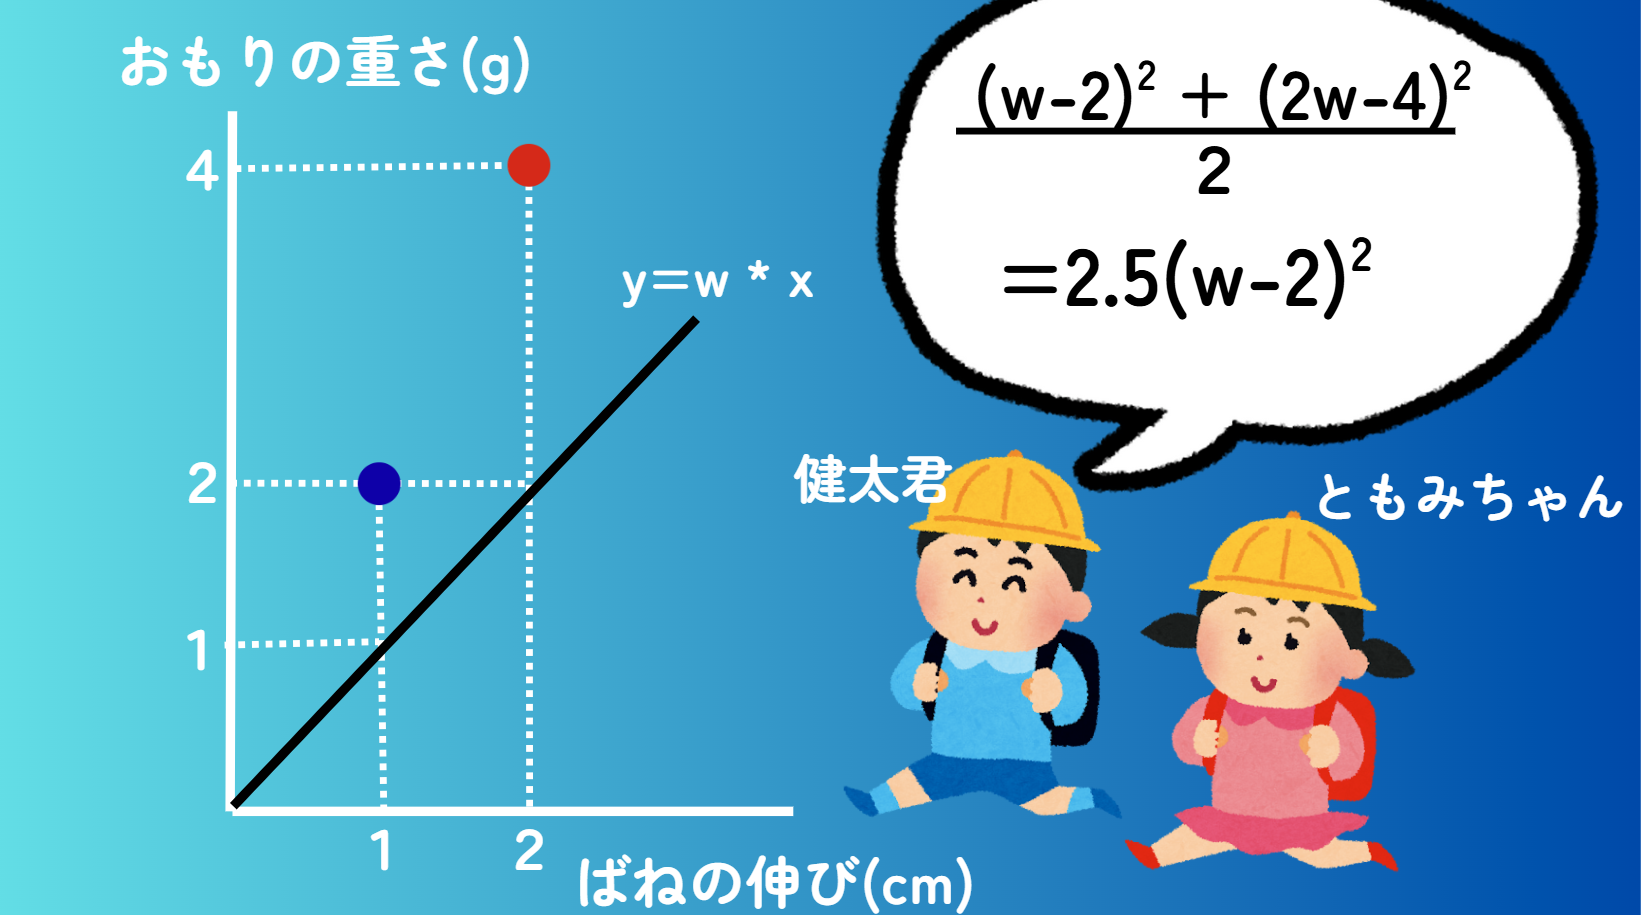

---

## 5. 数学的な「答え」を確認する

最後に、平方完成の結果に基づいて $w=2$ を代入し、誤差が $0$ になることを確認しましょう。

```python
出力: loss（平均二乗誤差/MSE）
式: (loss1 + loss2) / 2
```
- w=2 を代入した場合の最終的な損失値を確認します。理論上は0になるはずです。

In [ ]:
# 正解だと思われる w=2 を代入
w = 2

# 再計算。今までの関数のと誤差の平均の求め方を見直そう！
# 実際の値を代入するのではなく、今まで定義した関数を使って計算してみよう。
y_pred1 = # TODO: 出力 = 関数(引数)
y_pred2 = # TODO: 出力 = 関数(引数)

loss1 = # TODO: 出力 = 関数(引数)
loss2 = # TODO: 出力 = 関数(引数)

loss = # TODO: 出力 = 式　loss1とloss2を使って、サンプル平均の損失を計算してみましょう。

print(f"w=2 のときの誤差: {loss}") 

> **まとめ**
> 手計算（平方完成）で $w=2$ という答えが見つかりました。
> 次回は、データが複雑で手計算できない場合に、コンピュータが自動で $w$ を探す仕組みを学びます。


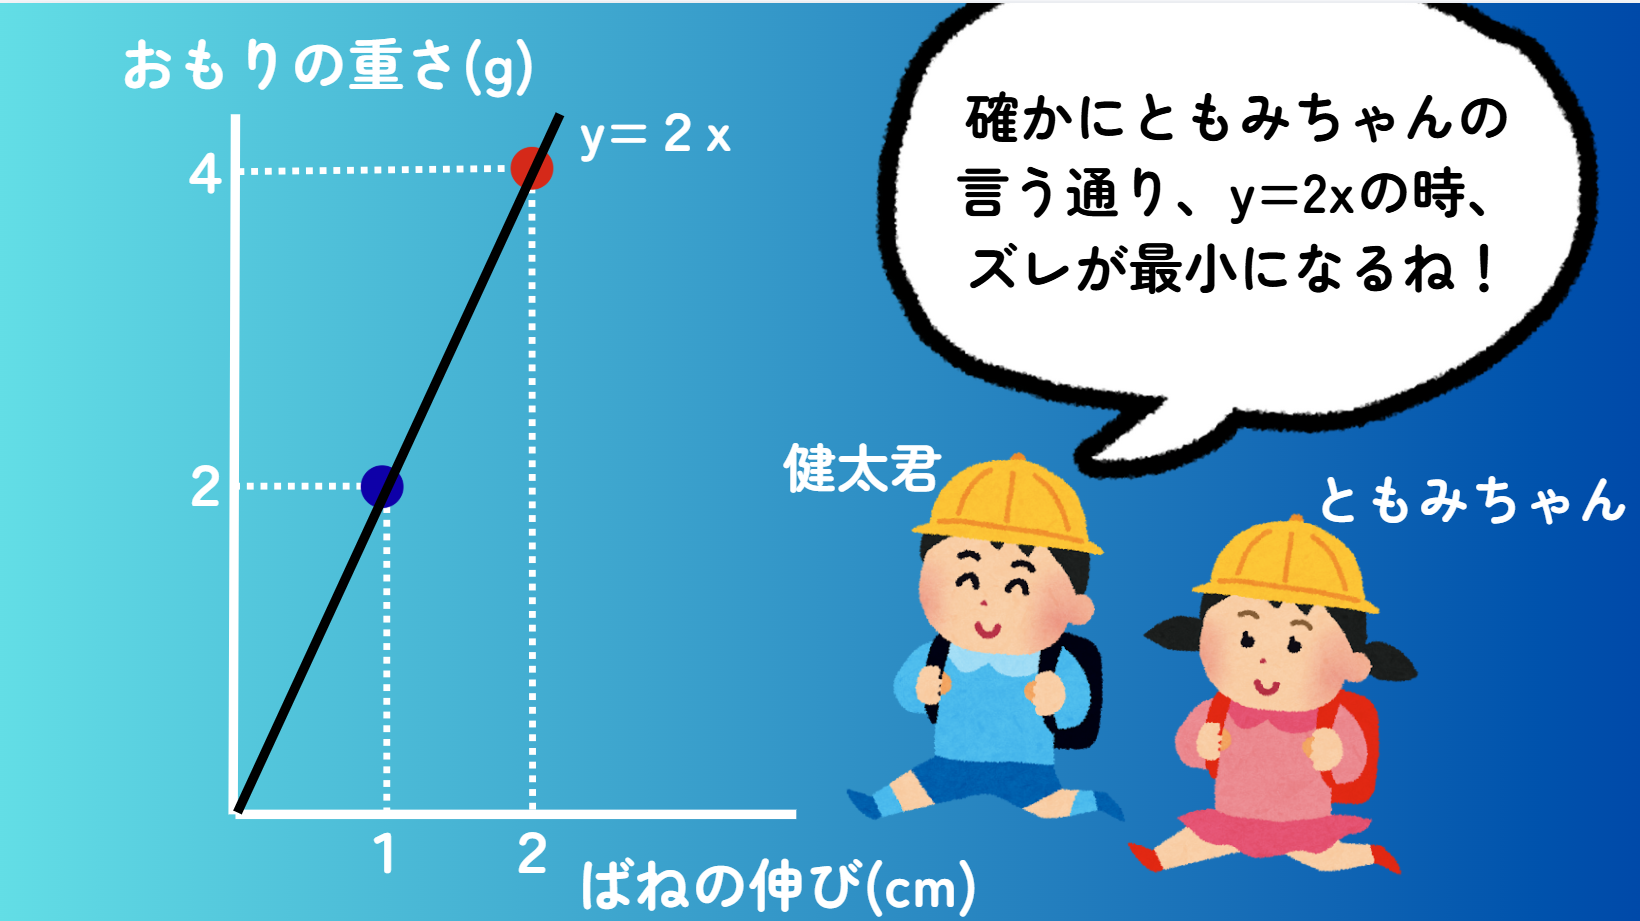

---

## 6. 導き出した法則から事象を再現する


予測した法則 $y = 2x$を利用して、事象を再現します。
おもりの重さ($y$)が与えられたときに、ばねの伸びの長さ($x$)を予測してみましょう。
ここでは、$y$から$x$を求める関数$Xpred$を定義します。

$$Xpred  = \frac{y}{w}$$

In [ ]:
def Xpred(y, w):
    return y / w

#おもりの重さyが3gのときの、ばねの伸びxを予測し、再現します。
x_pred = #TODO: 出力 = 関数(引数) 難しく考えないで！
print("x_pred", x_pred)

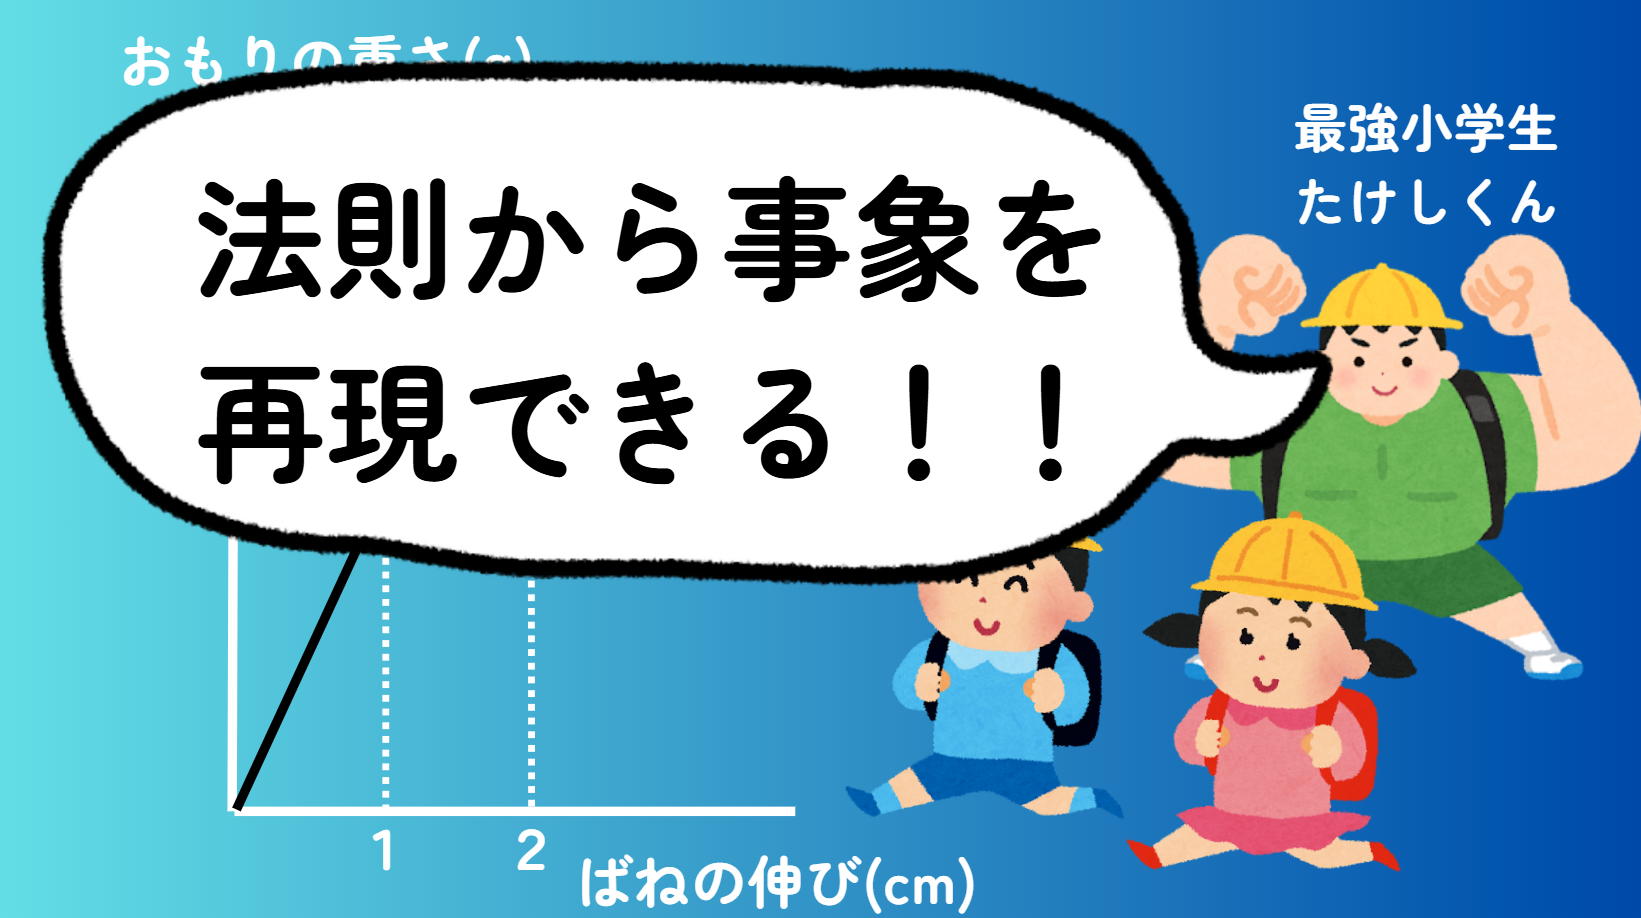